#**IDENTIFICAÇÃO**

**TITULO**: *Preditor de Overall de Jogadores FIFA 16-22 - Grupo 16*

**DISCENTES**:
Pedro Henrique Moura Andrade,
Ian Marcel Santos Santana,
Luis Gustavo Santos.

O dataset escolhido pode ser encontrado em https://www.kaggle.com/datasets/stefanoleone992/fifa-22-complete-player-dataset e traz métricas com base em estatísticas de jogadores de futebol.

O objetivo é utilizar modelos de aprendizado de máquina para prever nota geral (Overall) de atletas com base em atributos técnicos e físicos, e também avaliar qual deles obteve melhores resultados.

Atributo-alvo: Overall (nota geral)

Atributos preditivos: 'age', 'height_cm', 'weight_kg', 'weak_foot', 'international_reputation', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic','attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys','skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control','movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance','power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots','mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure','defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle','goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed', 'Is_CM', 'Is_CAM', 'Is_LM', 'Is_ST', 'Is_LW', 'Is_RW', 'Is_GK', 'Is_CB', 'Is_RM', 'Is_CF', 'Is_LB', 'Is_CDM', 'Is_RB', 'Is_RWB', 'Is_LWB'

Tipo de tarefa: Regresão


# Inicialização

Aqui estão todos os códigos que dizem respeito a inicialização do projeto, importação de bibliotecas e carregamento dos dados(.csv)

In [114]:
import numpy as np # importa a biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # importa a biblioteca usada para trabalhar com dataframes (dados em formato de tabela) e análise de dados

# bibliotecas usadas para geracao de graficos
import seaborn as sns
import matplotlib.pyplot as plt

print('Bibliotecas carregadas com sucesso')

# importa os arquivos e os guarda em dataframes do Pandas
df_female_2016 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_16.csv', sep=',', index_col=None)
df_female_2017 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_17.csv', sep=',', index_col=None)
df_female_2018 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_18.csv', sep=',', index_col=None)
df_female_2019 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_19.csv', sep=',', index_col=None)
df_female_2020 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_20.csv', sep=',', index_col=None)
df_female_2021 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_21.csv', sep=',', index_col=None)
df_female_2022 = pd.read_csv( 'https://raw.githubusercontent.com/PedroHenriqueMA/Overall_FIFA_Predictor/main/dataset/female/female_players_22.csv', sep=',', index_col=None)

# Concatena todos os dataframes em um só, sem unir os dados de mesmo index.
df_female = pd.concat([df_female_2016, df_female_2017, df_female_2018, df_female_2019, df_female_2020, df_female_2021, df_female_2022], ignore_index=True)

print('Dados importados com sucesso')

Bibliotecas carregadas com sucesso
Dados importados com sucesso


# 1. Compreensão dos dados

Nessa etapa vamos entender os dados que serão manipulados, entender sua organizanização e avaliar incosistências.

## 1.1 Registros e atributos
Ao todo são 2.244 registros de jogadoras femininas com 110 atributos, onde apenas 46 deles são relevantes. Após o pré-processamento dos dados se tornam 61 atributos

São cerca de 320 registros por ano, em média.



## 1.2 Tipos das variáveis

Entender os tipos de dados de cada atributo é crucial para o pré-processamento e modelagem. Abaixo, detalhamos 10 dos 46 atributos chave e seus tipos no `df_female`:

1.  **`overall`** (`int64`): A nota geral do jogador. Este é o nosso atributo-alvo de regressão, variando de 0 a 99.
2.  **`age`** (`int64`): A idade do jogador. Um atributo numérico direto.
3.  **`height_cm`** (`int64`): A altura do jogador em centímetros. Numérico.
4.  **`weight_kg`** (`int64`): O peso do jogador em quilogramas. Numérico.
5.  **`weak_foot`** (`int64`): A proficiência do jogador com o pé fraco, representada em estrelas (1 a 5). Embora seja um número inteiro, é conceitualmente uma variável categórica ordinal.
6.  **`international_reputation`** (`int64`): A reputação internacional do jogador, também em estrelas (1 a 5). Similar a `weak_foot`, é uma categórica ordinal.
7.  **`pace`** (`int64`): O atributo de ritmo/velocidade do jogador. Numérico.
8.  **`shooting`** (`int64`): O atributo de finalização do jogador. Numérico.
9.  **`mentality_composure`** (`float64`): A compostura mental do jogador. É um atributo numérico que pode ter valores decimais após o preenchimento de nulos.
10. **`player_positions`** (`object`, antes do pré-processamento): Originalmente, esta coluna continha strings que podiam listar múltiplas posições (ex: 'CM, CAM'). Para que os modelos pudessem utilizá-la, foi transformada em múltiplas colunas binárias (`is_CM`, `is_CAM`, `is_GK`, etc.) através do *One-Hot Encoding* na fase de pré-processamento. Por exemplo, `is_GK` (`int64`) indica se o jogador é um goleiro (1 para sim, 0 para não).


## 1.3 Valores Ausentes
Quanto aos valores dos registros, as jogadoras goleiras (player_position: GOL) não possuem os atributos: `pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`, total de 283 registros. Enquanto as jogadoras de outras posições não possuem o atributo `goalkeeping_speed`, total de 1961 registros.

Uma observação para os dados do ano de 2016, onde o atributo `mentality_composure` é nulo em todos os registros. Além de alguns atributos irrelevantes também se encontrarem nulos

Portanto, decidimos zerar os atributos ausentes para as goleiras, remover o atributo `goalkeeping_speed` e (Pensar no que fazer para mentality_composure)


## 1.4 Duplicações

Não há duplicações nos dados. Apesar de haver registros com repetições(id, nome, etc) por serem das mesmas jogadoras em anos diferentes. Porém, dados de mesmo ano não possuem duplicação ou chaves duplicadas.

## 1.5 Inconsistências

As principais inconsistências são:
* Nulos em goleiros para atributos de campo
* Nulos em jogadores de linha para atributo `goalkeeping_speed`
* `mentality_composure` nulo para registros de 2016
* Há colunas 100% nulas

Estas serão resolvidas e tratadas na etapa de pré-processamento

## 1.6 Distribuição do atributo-alvo;

Sobre a distribiução do "Overall" foi observado que:
* 25% é < 72
* 50% é < 76
* 75% é < 80
* Mediana: 76
* Média: 76,3
* Erro: 5,63
* Min: 57
* Max: 93

Disso tiramos conclusões interessantes:
* Metade dos dados está concentrado entre 72 e 80
* A margem que concentra os dados é 76,3 +/- 5,63 (71-82)
* Distribuição dos dados relativamente simétrica (média e mediana estão próximas)
* Distribuição inferior, 50% menores, vai de 57 a 76, amplitude de 19 pontos
* Distribuição Superior, 50% maiores, vai de 76 a 93, amplitude de 17 pontos

Essa concentração na amostragem não é um problema já que se trata de um problema de regressão, apenas leva a entender que o modelo possivelmente vai possuir maior precisão para valores na faixa de 70 a 80, do que para valores extremos muito baixos(57) ou muito altos(93). O mais relevante é a simetria observada que retrata boas condições para gerar uma boa precisão, pois caldas longas(assimetria) geram imprecisão nos modelos.

A distribuição dos dados de todos os anos segue a figura abaixo:

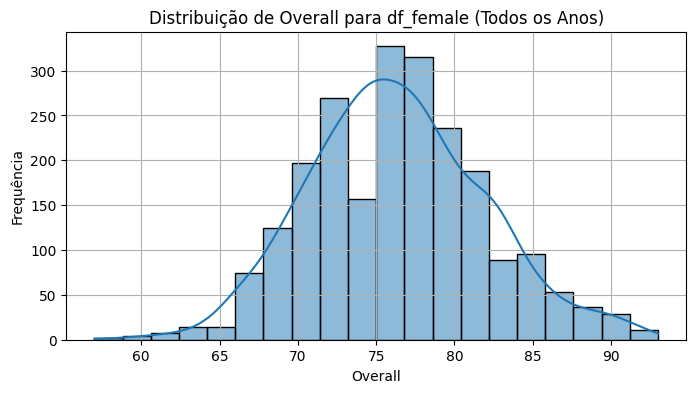

## 1.7 Código para analise do conjunto de dados
Para saber mais sobre dados estatísticos, analises, gráficos de distribuição e compreensão dos dados executar o código abaixo e ler a saída. Aqui há tanto os dados por ano quanto de todos os anos juntos.


--- Análise para df_female_2016 ---
Quantidade de registros: 248
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,248
wage_eur,248
club_team_id,248
club_name,248
league_name,248
league_level,248
club_position,248
club_jersey_number,248
club_loaned_from,248
club_joined,248



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    248.000000
mean      75.818548
std        5.469398
min       61.000000
25%       72.000000
50%       75.000000
75%       79.000000
max       91.000000
Name: overall, dtype: float64
Número de posições únicas: 85

Distribuição do Overall:


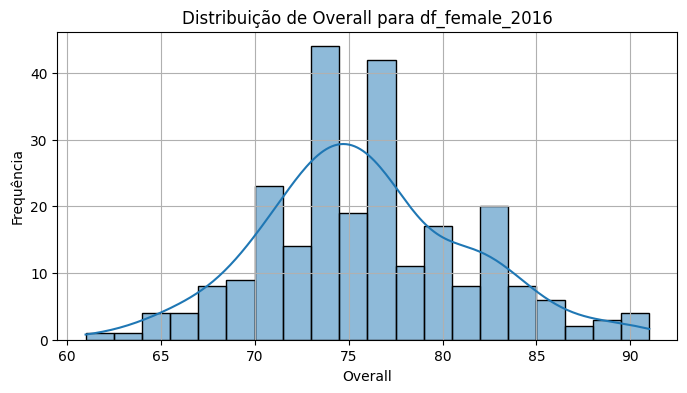

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    72.0
0.50    75.0
0.75    79.0
Name: overall, dtype: float64



--- Análise para df_female_2017 ---
Quantidade de registros: 299
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,299
wage_eur,299
club_team_id,299
club_name,299
league_name,299
league_level,299
club_position,299
club_jersey_number,299
club_loaned_from,299
club_joined,299



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    299.000000
mean      75.916388
std        5.552951
min       62.000000
25%       72.000000
50%       76.000000
75%       79.000000
max       92.000000
Name: overall, dtype: float64
Número de posições únicas: 92

Distribuição do Overall:


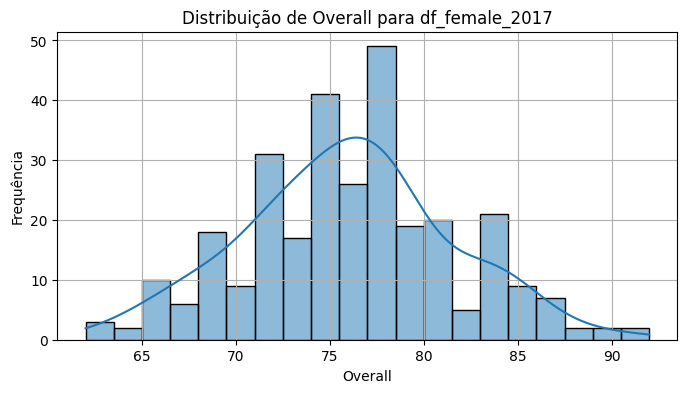

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    72.0
0.50    76.0
0.75    79.0
Name: overall, dtype: float64



--- Análise para df_female_2018 ---
Quantidade de registros: 317
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,317
wage_eur,317
club_team_id,317
club_name,317
league_name,317
league_level,317
club_position,317
club_jersey_number,317
club_loaned_from,317
club_joined,317



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    317.000000
mean      75.413249
std        5.634114
min       57.000000
25%       71.000000
50%       75.000000
75%       79.000000
max       92.000000
Name: overall, dtype: float64
Número de posições únicas: 100

Distribuição do Overall:


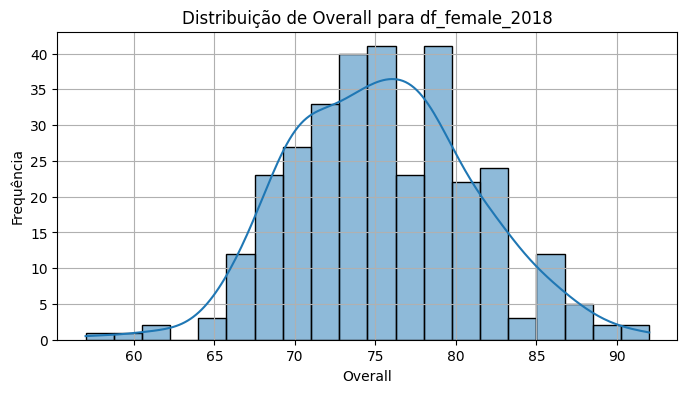

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    71.0
0.50    75.0
0.75    79.0
Name: overall, dtype: float64



--- Análise para df_female_2019 ---
Quantidade de registros: 299
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,299
wage_eur,299
club_team_id,299
club_name,299
league_name,299
league_level,299
club_position,299
club_jersey_number,299
club_loaned_from,299
club_joined,299



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    299.000000
mean      75.431438
std        5.425315
min       58.000000
25%       72.000000
50%       75.000000
75%       79.000000
max       89.000000
Name: overall, dtype: float64
Número de posições únicas: 107

Distribuição do Overall:


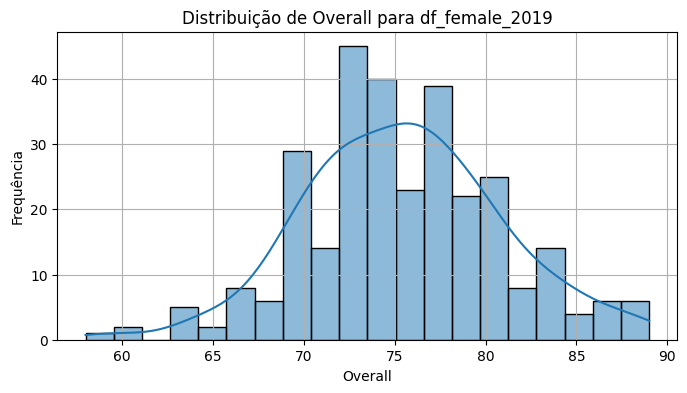

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    72.0
0.50    75.0
0.75    79.0
Name: overall, dtype: float64



--- Análise para df_female_2020 ---
Quantidade de registros: 345
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,345
wage_eur,345
club_team_id,345
club_name,345
league_name,345
league_level,345
club_position,345
club_jersey_number,345
club_loaned_from,345
club_joined,345



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    345.000000
mean      77.289855
std        5.642193
min       62.000000
25%       74.000000
50%       77.000000
75%       81.000000
max       93.000000
Name: overall, dtype: float64
Número de posições únicas: 122

Distribuição do Overall:


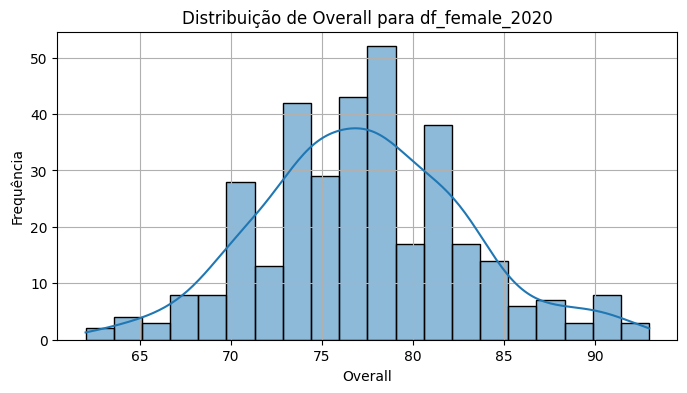

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    74.0
0.50    77.0
0.75    81.0
Name: overall, dtype: float64



--- Análise para df_female_2021 ---
Quantidade de registros: 345
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,345
wage_eur,345
club_team_id,345
club_name,345
league_name,345
league_level,345
club_position,345
club_jersey_number,345
club_loaned_from,345
club_joined,345



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    345.000000
mean      77.150725
std        5.609420
min       66.000000
25%       73.000000
50%       77.000000
75%       81.000000
max       93.000000
Name: overall, dtype: float64
Número de posições únicas: 115

Distribuição do Overall:


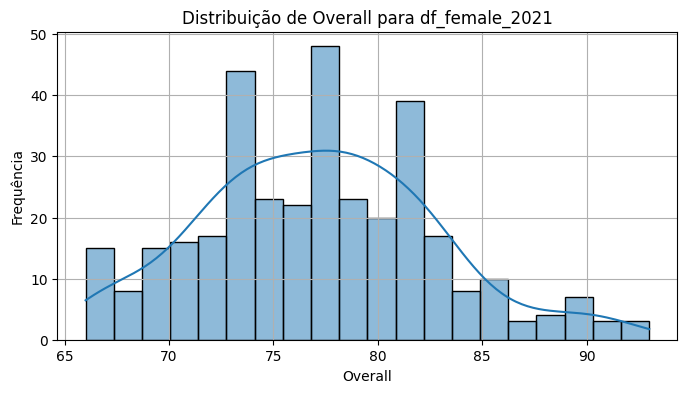

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    73.0
0.50    77.0
0.75    81.0
Name: overall, dtype: float64



--- Análise para df_female_2022 ---
Quantidade de registros: 391
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,345
wage_eur,345
club_team_id,391
club_name,391
league_name,391
league_level,391
club_position,391
club_jersey_number,391
club_loaned_from,391
club_joined,391



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica):
Estatísticas da coluna 'overall':
count    391.000000
mean      76.713555
std        5.744544
min       60.000000
25%       73.000000
50%       76.000000
75%       81.000000
max       92.000000
Name: overall, dtype: float64
Número de posições únicas: 124

Distribuição do Overall:


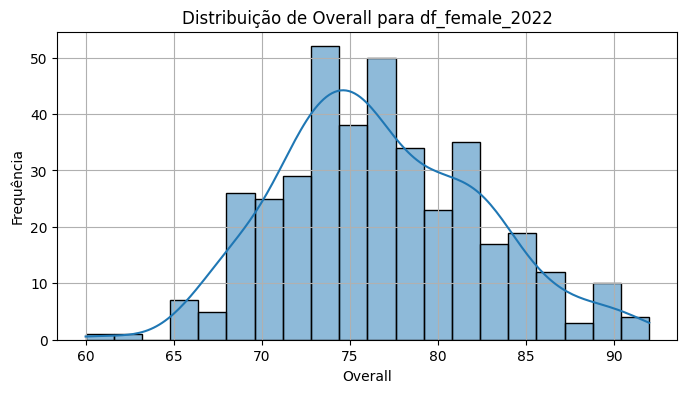

Desbalanceamento (distribuição do overall):
Quartis do 'overall':
0.25    73.0
0.50    76.0
0.75    81.0
Name: overall, dtype: float64



--- Análise Geral para df_female (Todos os Anos Combinados) ---
Quantidade de registros: 2244
Quantidade de atributos: 110

Tipos das variáveis:


,Dtype
sofifa_id,int64
player_url,object
short_name,object
long_name,object
player_positions,object
...,...
player_face_url,object
club_logo_url,float64
club_flag_url,float64
nation_logo_url,object



Valores ausentes:


,Null Count
value_eur,2198
wage_eur,2198
club_team_id,2244
club_name,2244
league_name,2244
league_level,2244
club_position,2244
club_jersey_number,2244
club_loaned_from,2244
club_joined,2244



Duplicações:
Número de linhas duplicadas: 0

Verificação de Inconsistências (básica) no DataFrame combinado:
Estatísticas da coluna 'overall':
count    2244.000000
mean       76.309715
std         5.636316
min        57.000000
25%        72.000000
50%        76.000000
75%        80.000000
max        93.000000
Name: overall, dtype: float64
Número de posições únicas: 234

Distribuição do Overall no DataFrame combinado:


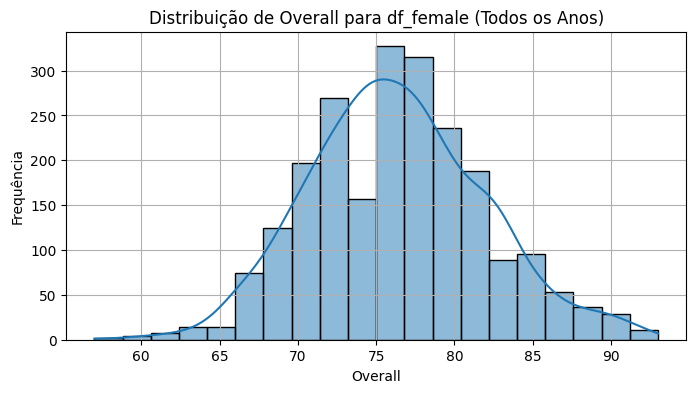

Desbalanceamento (distribuição do overall) no DataFrame combinado:
Quartis do 'overall':
0.25    72.0
0.50    76.0
0.75    80.0
Name: overall, dtype: float64




In [115]:
# Código completo que levou a compreensão dos dados

df_names_individual = {
    '2016': df_female_2016,
    '2017': df_female_2017,
    '2018': df_female_2018,
    '2019': df_female_2019,
    '2020': df_female_2020,
    '2021': df_female_2021,
    '2022': df_female_2022
}

for year, df in df_names_individual.items():
    print(f"\n--- Análise para df_female_{year} ---")

    # 1. Quantidade de registros e atributos
    print(f"Quantidade de registros: {df.shape[0]}")
    print(f"Quantidade de atributos: {df.shape[1]}")

    # 2. Tipos das variáveis
    print("\nTipos das variáveis:")
    display(df.dtypes.to_frame(name='Dtype'))

    # 3. Valores ausentes
    print("\nValores ausentes:")
    null_counts = df.isnull().sum()
    columns_with_nulls = null_counts[null_counts > 0]
    if not columns_with_nulls.empty:
        display(columns_with_nulls.to_frame(name='Null Count'))
    else:
        print("Não há valores nulos neste DataFrame.")

    # 4. Duplicações
    print("\nDuplicações:")
    duplicate_rows = df.duplicated().sum()
    print(f"Número de linhas duplicadas: {duplicate_rows}")
    if duplicate_rows > 0:
        print("Será necessário tratar as duplicações posteriormente.")

    # 5. Inconsistências (verificação básica para 'overall' e 'player_positions')
    print("\nVerificação de Inconsistências (básica):")
    if 'overall' in df.columns:
        print(f"Estatísticas da coluna 'overall':\n{df['overall'].describe()}")
    if 'player_positions' in df.columns:
        print(f"Número de posições únicas: {df['player_positions'].nunique()}")

    # 6. Distribuição do atributo-alvo (Overall)
    print("\nDistribuição do Overall:")
    if 'overall' in df.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df['overall'], kde=True, bins=20)
        plt.title(f'Distribuição de Overall para df_female_{year}')
        plt.xlabel('Overall')
        plt.ylabel('Frequência')
        plt.grid(True)
        plt.show()

        # 7. Análise de desbalanceamento (para 'overall', pode ser a distribuição)
        print("Desbalanceamento (distribuição do overall):")
        # Para um atributo-alvo contínuo como 'overall', desbalanceamento se refere a uma distribuição skewed
        # O histograma acima já mostra isso. Podemos complementar com quartis.
        print(f"Quartis do 'overall':\n{df['overall'].quantile([0.25, 0.5, 0.75])}")
    else:
        print("Coluna 'overall' não encontrada neste DataFrame.")

    print("\n" + "="*50 + "\n")

# Análise geral para o df_female
print("\n--- Análise Geral para df_female (Todos os Anos Combinados) ---")

# 1. Quantidade de registros e atributos
print(f"Quantidade de registros: {df_female.shape[0]}")
print(f"Quantidade de atributos: {df_female.shape[1]}")

# 2. Tipos das variáveis
print("\nTipos das variáveis:")
display(df_female.dtypes.to_frame(name='Dtype'))

# 3. Valores ausentes
print("\nValores ausentes:")
null_counts_total = df_female.isnull().sum()
columns_with_nulls_total = null_counts_total[null_counts_total > 0]
if not columns_with_nulls_total.empty:
    display(columns_with_nulls_total.to_frame(name='Null Count'))
else:
    print("Não há valores nulos no DataFrame combinado.")

# 4. Duplicações
print("\nDuplicações:")
duplicate_rows_total = df_female.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicate_rows_total}")
if duplicate_rows_total > 0:
    print("Será necessário tratar as duplicações posteriormente no DataFrame combinado.")

# 5. Inconsistências (verificação básica para 'overall' e 'player_positions')
print("\nVerificação de Inconsistências (básica) no DataFrame combinado:")
if 'overall' in df_female.columns:
    print(f"Estatísticas da coluna 'overall':\n{df_female['overall'].describe()}")
if 'player_positions' in df_female.columns:
    print(f"Número de posições únicas: {df_female['player_positions'].nunique()}")

# 6. Distribuição do atributo-alvo (Overall)
print("\nDistribuição do Overall no DataFrame combinado:")
if 'overall' in df_female.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_female['overall'], kde=True, bins=20)
    plt.title('Distribuição de Overall para df_female (Todos os Anos)')
    plt.xlabel('Overall')
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()

    # 7. Análise de desbalanceamento (para 'overall', pode ser a distribuição)
    print("Desbalanceamento (distribuição do overall) no DataFrame combinado:")
    print(f"Quartis do 'overall':\n{df_female['overall'].quantile([0.25, 0.5, 0.75])}")
else:
    print("Coluna 'overall' não encontrada no DataFrame combinado.")

print("\n" + "="*50 + "\n")

# 2. Pré-Processamento


## 2.1 Seleção de atributos

In [116]:
# Eliminação das colunas inúteis
columns_to_keep = [
    'overall', 'player_positions', 'age', 'height_cm', 'weight_kg', 'weak_foot', 'international_reputation',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing', 'attacking_volleys',
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
    'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 'mentality_composure',
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle',
    'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes', 'goalkeeping_speed',
]

# Aplica a filtragem de colunas a cada DataFrame de ano
df_female_2016 = df_female_2016[columns_to_keep]
df_female_2017 = df_female_2017[columns_to_keep]
df_female_2018 = df_female_2018[columns_to_keep]
df_female_2019 = df_female_2019[columns_to_keep]
df_female_2020 = df_female_2020[columns_to_keep]
df_female_2021 = df_female_2021[columns_to_keep]
df_female_2022 = df_female_2022[columns_to_keep]

## 2.2 Função preprocess

Aqui é feito, o tratamento das inconsistências de nulos em`pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic` e  `goalkeeping_speed`, assim como a criação das colunas binárias para `player_positions` e sua remoção

In [117]:
# Determina todas as posições únicas do DataFrame completo
all_positions = df_female['player_positions'].str.split(', ').explode().unique()
all_positions = [pos for pos in all_positions if pd.notna(pos)]
print(f"Foram identificadas {len(all_positions)} posições únicas do conjunto completo: {all_positions}")

def preprocess_dataframe(df):
    # Garante que estamos trabalhando com uma cópia para evitar SettingWithCopyWarning
    df = df.copy()

    # 1. Atribuindo zero ao atributo goalkeeping_speed onde valor NaN (para jogadores de linha)
    df['goalkeeping_speed'] = df['goalkeeping_speed'].fillna(0)

    # 2. Preenchendo valores nulos para atributos de campo (goleiros)
    columns_to_fill_with_zero_for_goalkeepers = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']
    df[columns_to_fill_with_zero_for_goalkeepers] = df[columns_to_fill_with_zero_for_goalkeepers].fillna(0)

    # 3. Criação de colunas binárias para 'player_positions' (One-Hot Encoding)
    for position in all_positions:
        df[f'is_{position}'] = df['player_positions'].apply(lambda x: 1 if position in str(x) else 0)

    # 4. Remoção das colunas originais após transformação
    df = df.drop(columns=['player_positions', 'primary_position_for_imputation'], errors='ignore')

    return df

Foram identificadas 15 posições únicas do conjunto completo: ['CM', 'CAM', 'LM', 'ST', 'LW', 'RW', 'GK', 'CB', 'RM', 'CF', 'LB', 'CDM', 'RB', 'RWB', 'LWB']


### 2.2.1 Explicação do Tratamento de Inconsistências

1. O problema com nulos no campo `goalkeeping_speed` foi resolvido atribuindo zero onde não havia valor (jogadores não goleiros)
2. Onde os atributos de campo `pace`, `shooting`, ... eram nulos (goleiros) foi atribuido zero

Quanto aos valores nulos no `mentality_composure` a abordagem tomada foi diferente, atribuir a média por posição e overall, tendo como objetivo aumentar o `mentality_composure` para grupos que tem maior valor nesse atributo e reduzi-lo para grupos que tem menor valor nesse atributo, o objetivo com isso é não prejudicar o treinamento com os dados de 2016. No caso de não haver outros jogadores de mesma posição e overall atribui-se a média global do atributo.

### 2.2.2 Explicação One-Hot Encoding
Como `player_positions` pode conter múltiplas posições por jogador, criamos novas colunas binárias (0 ou 1) para cada posição única. Isso permite que o modelo entenda as múltiplas funções de um jogador sem assumir uma ordem. Após isso, podemos remover `player_positions` para evitar redundância e focar nos atributos transformados e relevantes, já que as posições estão sendo representadas em colunas binárias.

## 2.3 Execução Pré-Processamento

In [118]:
# --- Tratamento especial para 'mentality_composure' do df_female_2016 ---
# Como 'mentality_composure' é totalmente nulo em 2016, calcularemos as médias dos outros anos (2017-2022) para imputar o df_female_2016.

# 1. Combina os DataFrames de 2017 a 2022 para calcular as médias
df_non_2016_temp = pd.concat([
    df_female_2017, df_female_2018, df_female_2019,
    df_female_2020, df_female_2021, df_female_2022
], ignore_index=True)

# Adiciona temporariamente 'primary_position_for_imputation' para calcular médias agrupadas
df_non_2016_temp['primary_position_for_imputation'] = df_non_2016_temp['player_positions'].apply(lambda x: str(x).split(', ')[0] if pd.notna(x) else None)

# Calcula a média por posição principal e overall dos anos 2017-2022
mean_composure_grouped_non_2016 = df_non_2016_temp.groupby(['primary_position_for_imputation', 'overall'])['mentality_composure'].mean()

# Calcula a média geral de 'mentality_composure' dos anos 2017-2022 como fallback
global_fallback_mean_non_2016 = df_non_2016_temp['mentality_composure'].mean()

# Libera memória do DataFrame temporário
del df_non_2016_temp

print(f"Média global de 'mentality_composure' (2017-2022): {global_fallback_mean_non_2016:.2f}")

# 2. Preenche 'mentality_composure' no df_female_2016 usando as médias calculadas
df_female_2016_copy = df_female_2016.copy() # Trabalha em uma cópia para evitar warnings

# Adiciona 'primary_position_for_imputation' ao df_female_2016 para o merge/map
df_female_2016_copy['primary_position_for_imputation'] = df_female_2016_copy['player_positions'].apply(lambda x: str(x).split(', ')[0] if pd.notna(x) else None)

df_female_2016_copy = df_female_2016_copy.set_index(['primary_position_for_imputation', 'overall'])
df_female_2016_copy['mentality_composure'] = df_female_2016_copy['mentality_composure'].fillna(mean_composure_grouped_non_2016)
df_female_2016_copy = df_female_2016_copy.reset_index()

# Preenche quaisquer nulos remanescentes com a média global dos anos 2017-2022
df_female_2016_copy['mentality_composure'] = df_female_2016_copy['mentality_composure'].fillna(global_fallback_mean_non_2016)

# Remove a coluna temporária do df_female_2016_copy
df_female_2016 = df_female_2016_copy.drop(columns=['primary_position_for_imputation'], errors='ignore')

print("Valores nulos de 'mentality_composure' em df_female_2016 preenchidos com médias de outros anos.")

Média global de 'mentality_composure' (2017-2022): 66.23
Valores nulos de 'mentality_composure' em df_female_2016 preenchidos com médias de outros anos.


In [119]:
# Aplica a função preprocess para o DataFrame de cada ano
df_female_2016_processed = preprocess_dataframe(df_female_2016)
df_female_2017_processed = preprocess_dataframe(df_female_2017)
df_female_2018_processed = preprocess_dataframe(df_female_2018)
df_female_2019_processed = preprocess_dataframe(df_female_2019)
df_female_2020_processed = preprocess_dataframe(df_female_2020)
df_female_2021_processed = preprocess_dataframe(df_female_2021)
df_female_2022_processed = preprocess_dataframe(df_female_2022)

# Concatena os dados pré-processados no df_female
df_female = pd.concat([
    df_female_2016_processed,
    df_female_2017_processed,
    df_female_2018_processed,
    df_female_2019_processed,
    df_female_2020_processed,
    df_female_2021_processed,
    df_female_2022_processed
], ignore_index=True)

In [120]:
# Exibir todas as colunas do DataFrame para ver o resultado completo
pd.options.display.max_columns = None
display(df_female.head())
display(df_female.tail())
pd.options.display.max_columns = 20

,overall,age,height_cm,weight_kg,weak_foot,international_reputation,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,is_CM,is_CAM,is_LM,is_ST,is_LW,is_RW,is_GK,is_CB,is_RM,is_CF,is_LB,is_CDM,is_RB,is_RWB,is_LWB
0,91,32,173,64,3,5,75.0,83.0,83.0,85.0,82.0,84.0,72,83,71,88,64,86,76,80,87,86,75,75,74,91,77,81,77,92,81,89,84,90,90,86,82,66.231964,76,86,79,11,5,13,8,14,0.0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0
1,90,29,170,60,5,5,74.0,74.0,90.0,89.0,46.0,68.0,94,73,65,93,72,92,86,78,91,91,74,74,83,84,69,77,74,84,73,71,35,45,84,86,84,66.231964,42,44,46,13,10,12,12,9,0.0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0
2,90,35,180,81,4,5,72.0,89.0,65.0,80.0,39.0,82.0,53,93,91,71,83,82,53,59,66,83,73,72,56,91,75,86,62,74,94,83,68,35,91,71,86,88.600000,39,28,27,10,10,12,12,13,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
3,90,28,168,56,4,5,84.0,74.0,87.0,90.0,53.0,69.0,84,76,58,91,80,90,78,81,83,92,85,83,91,89,78,72,54,80,68,67,60,52,84,91,85,66.231964,51,56,44,11,13,5,13,12,0.0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
4,89,27,169,61,3,5,74.0,84.0,85.0,83.0,78.0,74.0,76,87,76,90,78,84,75,72,88,85,75,73,73,91,73,80,69,77,73,82,76,86,86,88,82,66.231964,68,82,77,11,15,9,9,9,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


,overall,age,height_cm,weight_kg,weak_foot,international_reputation,pace,shooting,passing,dribbling,defending,physic,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,movement_acceleration,movement_sprint_speed,movement_agility,movement_reactions,movement_balance,power_shot_power,power_jumping,power_stamina,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,goalkeeping_speed,is_CM,is_CAM,is_LM,is_ST,is_LW,is_RW,is_GK,is_CB,is_RM,is_CF,is_LB,is_CDM,is_RB,is_RWB,is_LWB
2239,66,18,170,58,3,1,71.0,63.0,65.0,72.0,31.0,49.0,61,67,58,70,51,72,57,57,66,70,76,66,81,62,80,56,67,52,53,65,31,21,60,65,65,58.0,30,28,34,10,11,6,12,5,0.0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
2240,66,23,171,60,3,1,75.0,67.0,51.0,63.0,16.0,60.0,40,68,66,60,57,60,45,48,38,64,74,75,68,64,70,67,74,68,67,66,28,11,65,58,69,60.0,10,10,12,12,6,11,6,10,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
2241,66,19,168,64,2,1,72.0,69.0,55.0,67.0,35.0,51.0,54,72,60,60,58,68,51,49,55,68,74,71,68,55,68,67,64,57,54,69,34,34,66,52,60,54.0,33,31,27,9,7,6,5,15,0.0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
2242,62,19,168,65,3,1,71.0,25.0,52.0,57.0,55.0,53.0,62,22,46,58,24,51,32,28,54,58,72,70,73,53,81,28,55,65,44,20,61,51,46,41,32,50.0,46,67,65,9,11,13,12,7,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2243,60,19,172,70,2,1,68.0,29.0,49.0,58.0,56.0,59.0,44,30,40,58,26,56,36,34,56,58,70,67,62,58,75,24,57,59,62,26,54,60,44,41,33,52.0,51,62,60,7,14,11,7,14,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0


# 3. Separação

Vamos preparar os dados para treinamento e teste, utilizando uma abordagem de divisão baseada no tempo(Time-Series Split). Isso é crucial para evitar vazamento de dados (data leakage) e garantir que o modelo seja avaliado de forma realista, prevendo valores para dados 'futuros' que ele nunca viu antes.

Primeiro, vamos adicionar uma coluna de `year` ao DataFrame `df_female` para identificar o ano de cada registro, o que facilitará a divisão temporal.

In [121]:
# Reconcatena os DataFrames já processados, adicionando a coluna 'year'
df_female = pd.concat([
    df_female_2016_processed.assign(year=2016),
    df_female_2017_processed.assign(year=2017),
    df_female_2018_processed.assign(year=2018),
    df_female_2019_processed.assign(year=2019),
    df_female_2020_processed.assign(year=2020),
    df_female_2021_processed.assign(year=2021),
    df_female_2022_processed.assign(year=2022)
], ignore_index=True)

display(df_female.head(2))
display(df_female.tail(2))

,overall,age,height_cm,weight_kg,weak_foot,international_reputation,pace,shooting,passing,dribbling,...,is_GK,is_CB,is_RM,is_CF,is_LB,is_CDM,is_RB,is_RWB,is_LWB,year
0,91,32,173,64,3,5,75.0,83.0,83.0,85.0,...,0,0,0,0,0,0,0,0,0,2016
1,90,29,170,60,5,5,74.0,74.0,90.0,89.0,...,0,0,0,0,0,0,0,0,0,2016


,overall,age,height_cm,weight_kg,weak_foot,international_reputation,pace,shooting,passing,dribbling,...,is_GK,is_CB,is_RM,is_CF,is_LB,is_CDM,is_RB,is_RWB,is_LWB,year
2242,62,19,168,65,3,1,71.0,25.0,52.0,57.0,...,0,0,0,0,1,0,0,0,0,2022
2243,60,19,172,70,2,1,68.0,29.0,49.0,58.0,...,0,1,0,0,0,0,1,0,0,2022


Agora, o `df_female` é dividido em conjuntos de treinamento e teste, usando os dados até 2021 para treinamento e os dados de 2022 para teste. E em seguida separado o atributo-alvo dos preditores.

In [122]:
# Definir o ano de corte para a divisão
TEST_YEAR = 2022

# Dividir os dados em treinamento e teste com base no ano
df_train = df_female[df_female['year'] < TEST_YEAR]
df_test = df_female[df_female['year'] == TEST_YEAR]

# Separando o alvo (y) e os preditores (X), removendo colunas não preditivas
y_train = df_train['overall']
X_train = df_train.drop(columns=['overall', 'year'])

y_test = df_test['overall']
X_test = df_test.drop(columns=['overall', 'year'])

print(f"Quantidade de dados de Treino (2016-2021): {X_train.shape[0]}")
print(f"Quantidade de dados de Teste (2022): {X_test.shape[0]}\n")

Quantidade de dados de Treino (2016-2021): 1853
Quantidade de dados de Teste (2022): 391



# 4. Análise Exploratória

Nesta seção, realizaremos uma Análise Exploratória de Dados para entender melhor as características do nosso conjunto de dados de treinamento (`df_train`). O objetivo é visualizar a distribuição das variáveis, identificar possíveis relações entre elas e o atributo alvo (`overall`), e detectar anomalias ou padrões que possam influenciar a modelagem.

> Observação: Como na compreensão dos dados já fizemos uma discussão da distribuição do atributo e de questões quantitativas e estatísticas dos dados, elas foram retiradas dessa sessão.

### 4.1 Histograma de Atributos Chave

Vamos visualizar a distribuição de alguns atributos preditivos importantes usando histogramas. Isso nos ajuda a identificar a forma da distribuição, a presença de múltiplos modos e possíveis valores atípicos.

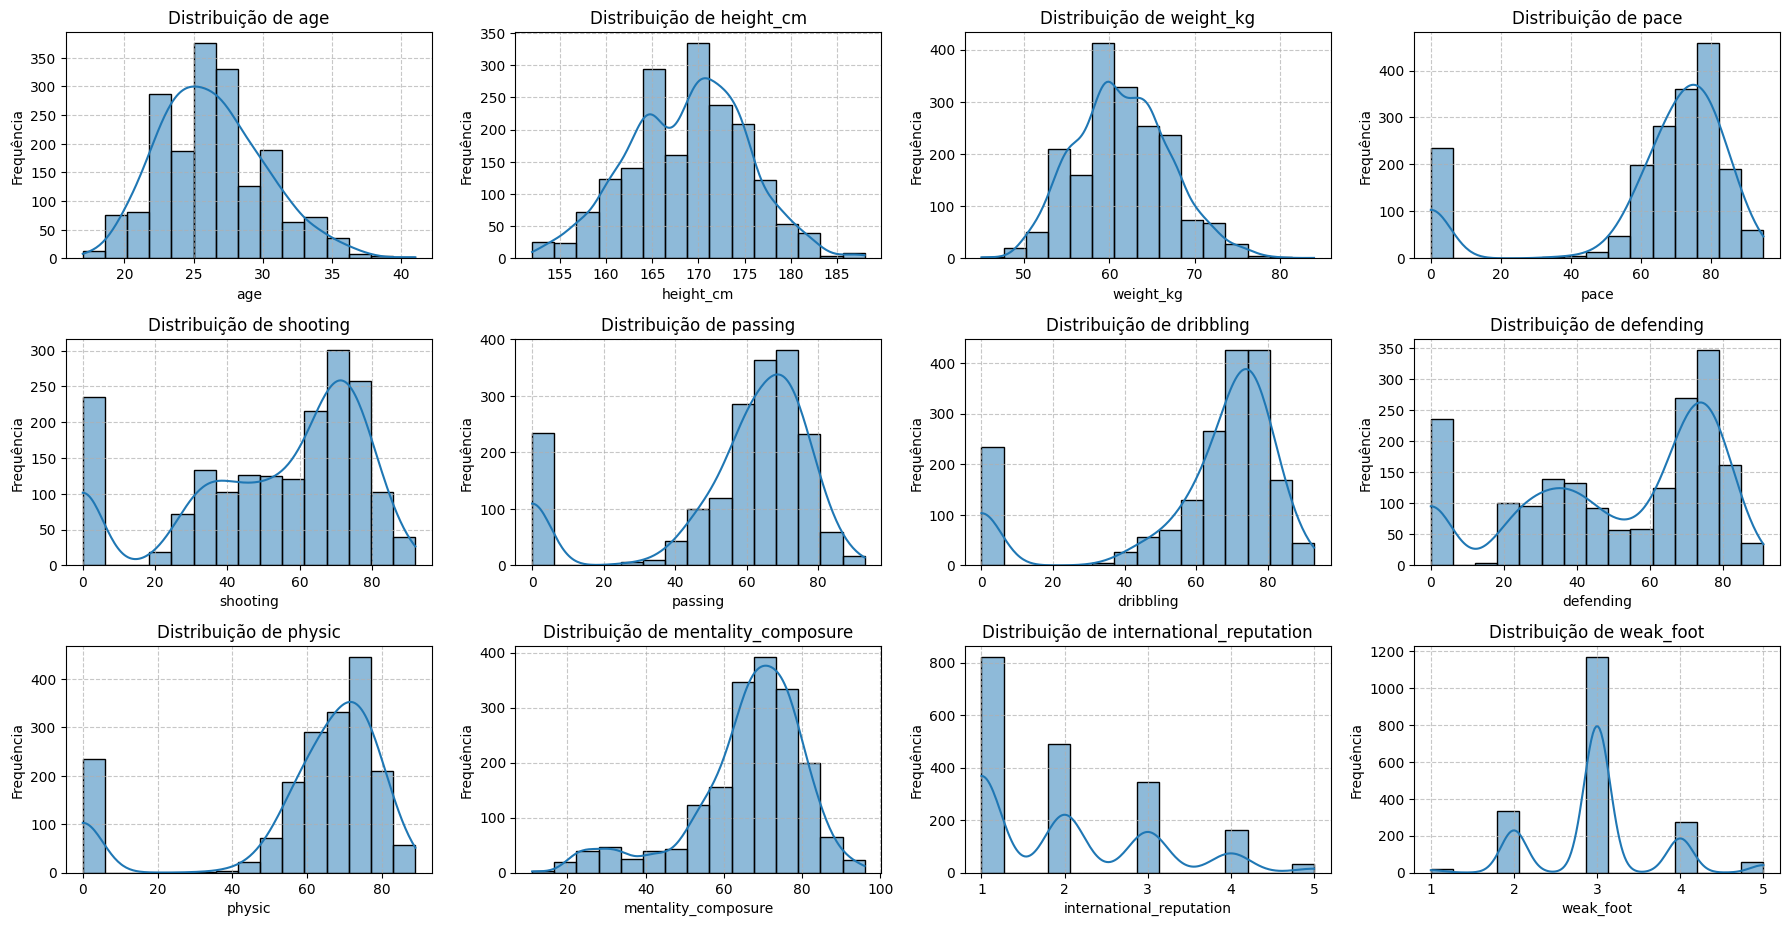

In [123]:
key_features = [
    'age', 'height_cm', 'weight_kg', 'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic', 'mentality_composure',
    'international_reputation', 'weak_foot'
]

plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_features):
    plt.subplot(4, 4, i + 1) # 4 linhas, 4 colunas
    sns.histplot(df_train[feature], kde=True, bins=15)
    plt.title(f'Distribuição de {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequência')
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Os histogramas para os atributos-chave selecionados, como 'age', 'height_cm', 'weight_kg' e diversas habilidades, revelam as distribuições individuais de cada preditor. A observação desses gráficos permite identificar se as variáveis são simétricas, assimétricas, multimodais ou se concentram em faixas específicas de valores. Essa compreensão é crucial para decidir sobre a necessidade de transformações de variáveis, como logaritmização ou padronização, e para entender a estrutura inerente aos dados antes da modelagem. Uma observação é que nos atributos de campo (`pace`, `physic`, `shooting`, `passing`, `dribbling`, `defending`) há um pico em zero, pois todos os goleiros não tinham nenhum valor nesses atributos e portanto tivemos de realizar esse tratamento.

### 4.2 Boxplots de Atributos Chave

Os boxplots são úteis para visualizar a distribuição de um atributo numérico, mostrando a mediana, quartis e identificando possíveis outliers. Vamos aplicá-los aos mesmos atributos chave.

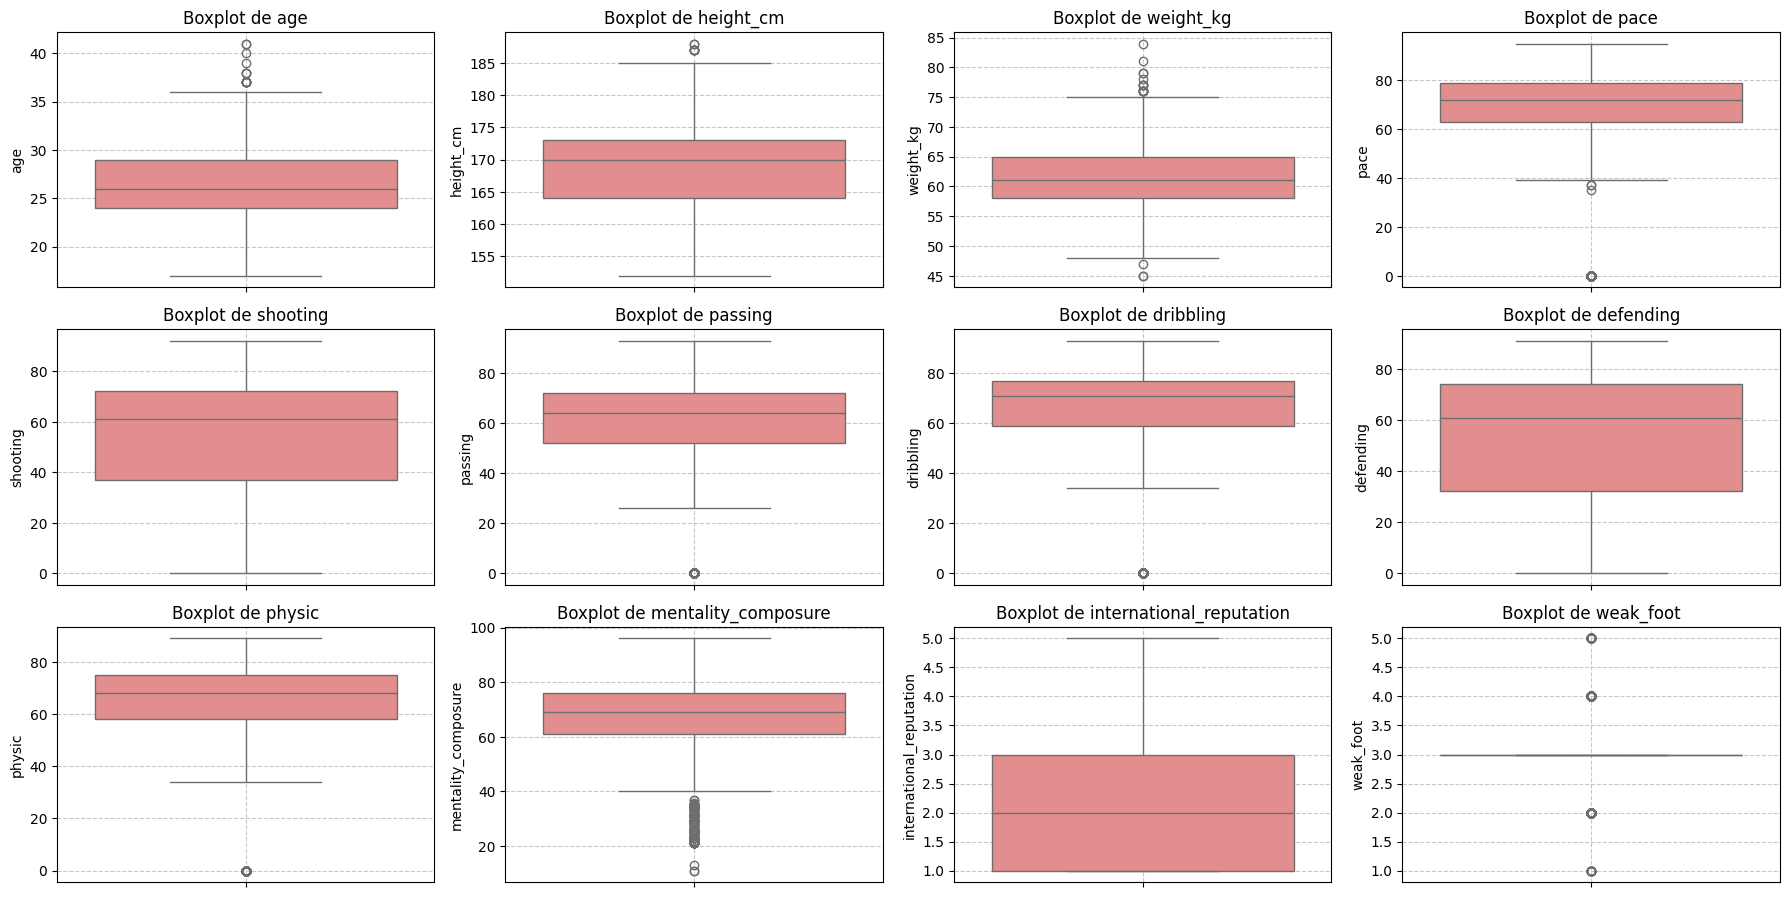

In [124]:
plt.figure(figsize=(18, 12))
for i, feature in enumerate(key_features):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df_train[feature], color='lightcoral')
    plt.title(f'Boxplot de {feature}')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Os boxplots fornecem uma representação visual concisa da distribuição de cada atributo numérico chave, destacando a mediana, os quartis (25% e 75%) e a presença de possíveis valores atípicos (outliers). Ao analisar esses gráficos, podemos identificar rapidamente a dispersão dos dados, detectar valores extremos que podem ser anomalias ou dados válidos, e entender a simetria ou assimetria da distribuição de cada atributo. Isso é útil para avaliar a robustez dos modelos a serem utilizados ou a necessidade de tratamento de outliers.

### 4.3 Matriz de Correlação

A matriz de correlação nos permite entender a relação linear entre pares de variáveis. Uma alta correlação (positiva ou negativa) pode indicar que duas variáveis se movem juntas, enquanto uma correlação próxima de zero sugere pouca ou nenhuma relação linear. Vamos focar na correlação com a variável alvo `overall`.

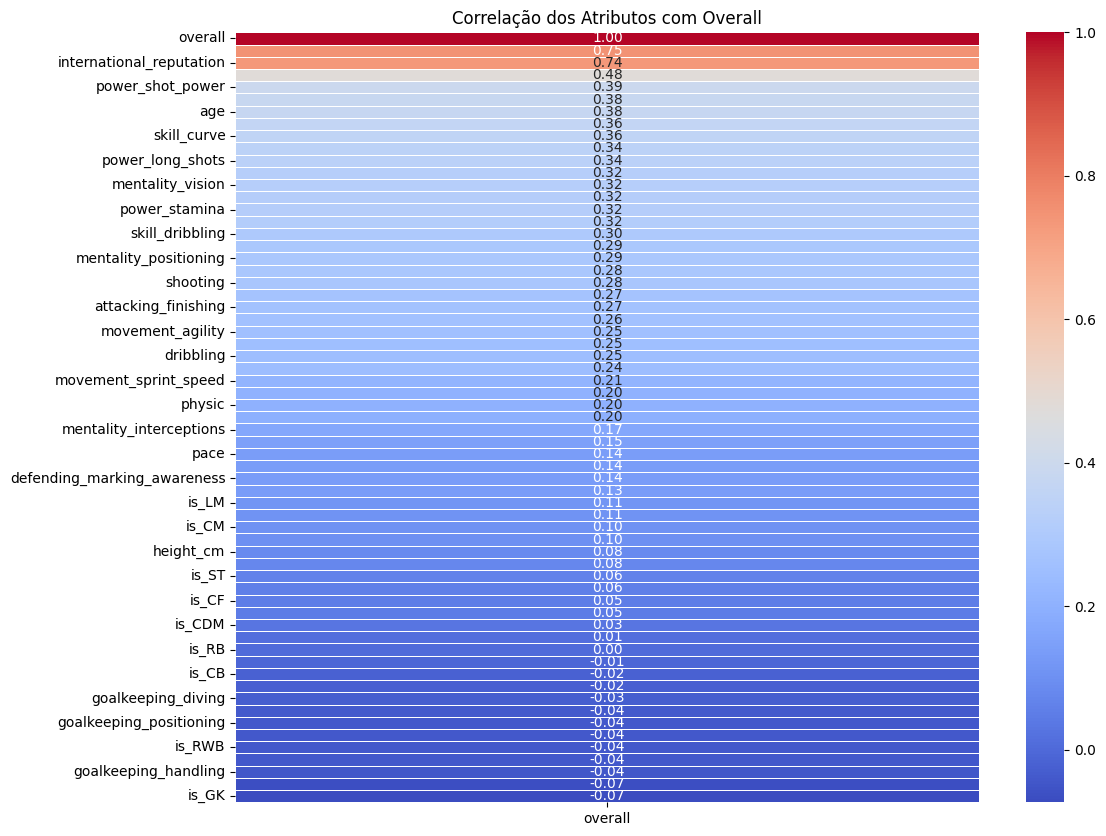

In [125]:
plt.figure(figsize=(12, 10))
correlation_matrix = df_train.corr(numeric_only=True)
sns.heatmap(correlation_matrix[['overall']].sort_values(by='overall', ascending=False), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlação dos Atributos com Overall')
plt.show()

O mapa de calor da matriz de correlação, focado na variável `overall`, visualiza as relações lineares entre os atributos preditores e o alvo. Atributos com alta correlação (positiva ou negativa) com `overall` são fortes candidatos a preditores importantes no modelo de regressão, enquanto aqueles com correlação próxima de zero podem ter um impacto linear menor. Essa análise ajuda a direcionar a seleção de características e a compreender as interdependências entre as variáveis.

### 4.4 Relações entre Atributos e o Alvo (`overall`)

Vamos investigar mais a fundo a relação entre algumas das variáveis mais correlacionadas e o `overall` usando gráficos de dispersão.

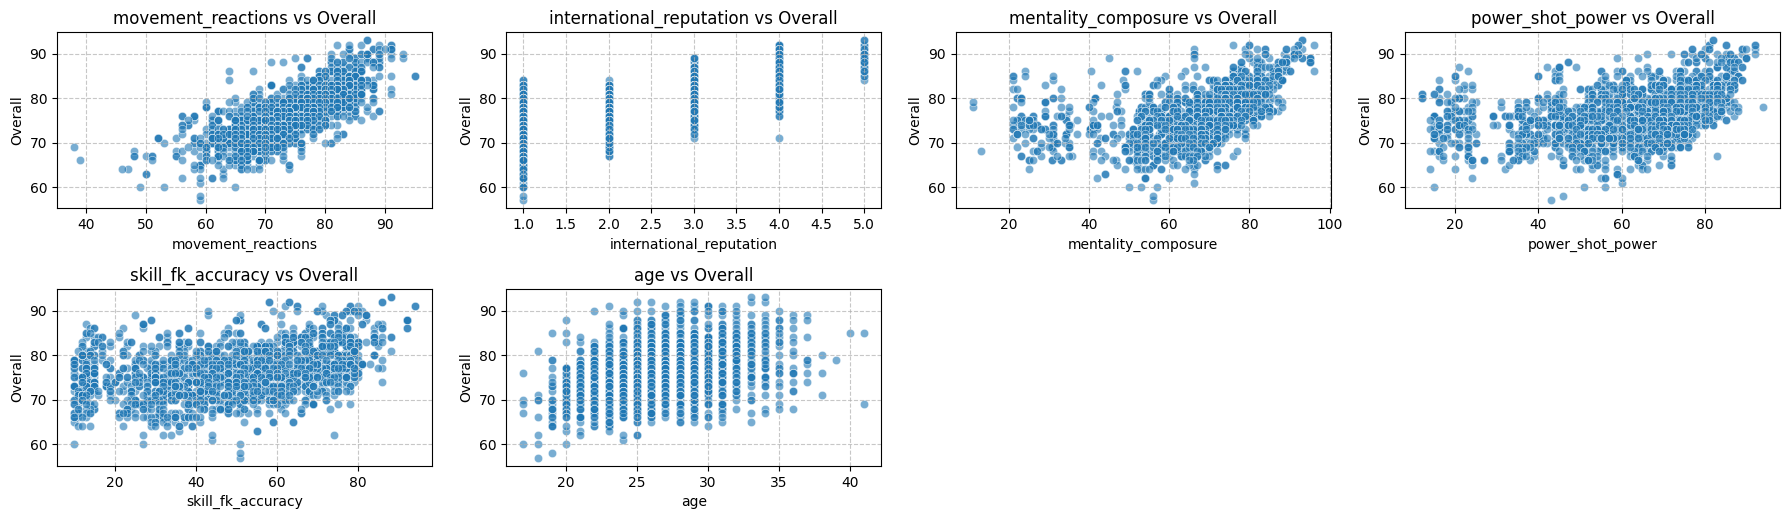

In [126]:
top_correlated_features = correlation_matrix['overall'].abs().sort_values(ascending=False).index[1:7] # Excluir 'overall' do top

plt.figure(figsize=(18, 10))
for i, feature in enumerate(top_correlated_features):
    plt.subplot(4, 4, i + 1) # 2 linhas, 3 colunas
    sns.scatterplot(x=df_train[feature], y=df_train['overall'], alpha=0.6)
    plt.title(f'{feature} vs Overall')
    plt.xlabel(feature)
    plt.ylabel('Overall')
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Os gráficos de dispersão entre `overall` e os atributos mais correlacionados oferecem uma visualização mais detalhada das tendências identificadas na matriz de correlação. Eles permitem observar se a relação é predominantemente linear, curvilínea, ou se existem padrões mais complexos, como agrupamentos de dados. Esta análise gráfica complementa o coeficiente de correlação, fornecendo um contexto visual sobre a forma e a força dessas relações, o que é valioso para a escolha e o entendimento dos modelos. Mais a frente traremos uma abordagem que deixa mais claro essa observação da relação entre as variáveis.

### 4.5 Análise de Atributos Categóricos/Binários (`is_Position`)

As colunas `is_Position` indicam se um jogador ocupa uma determinada posição. Vamos analisar como a média do `overall` varia para jogadores em diferentes posições, o que pode revelar a importância dessas categorias para a previsão.

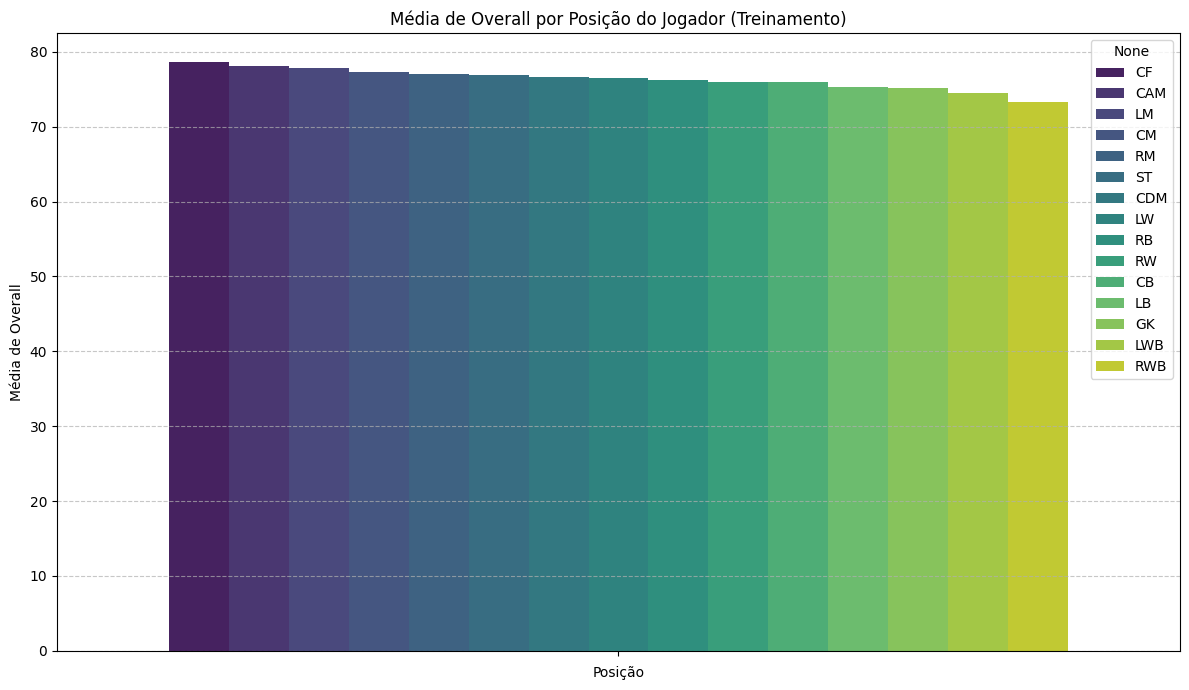

In [127]:
position_columns = [col for col in df_train.columns if col.startswith('is_')]

average_overall_by_position = {}
for pos_col in position_columns:
    if pos_col in df_train.columns:
        # Calcula a média do overall para jogadores que possuem essa posição
        mean_overall = df_train[df_train[pos_col] == 1]['overall'].mean()
        position_name = pos_col.replace('is_', '')
        average_overall_by_position[position_name] = mean_overall

avg_overall_df = pd.DataFrame.from_dict(average_overall_by_position, orient='index', columns=['Average Overall'])
avg_overall_df = avg_overall_df.sort_values(by='Average Overall', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(hue=avg_overall_df.index, y=avg_overall_df['Average Overall'], palette='viridis')
plt.title('Média de Overall por Posição do Jogador (Treinamento)')
plt.xlabel('Posição')
plt.ylabel('Média de Overall')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

O gráfico de barras que exibe a média do `overall` por posição de jogador (`is_CM`, `is_GK`, etc.) é fundamental para entender a influência da função de um jogador em sua avaliação geral. A variação nas médias de `overall` entre diferentes posições indica que a especialização do jogador é um fator significativo em sua classificação. Isso pode ser um insight valioso para o modelo, confirmando que a posição é um preditor relevante do desempenho geral. Uma característica interessante dos dados é que posições como RWB (ala direito) e LWB (ala esquerdo) possuem menos `overall` que a posição de CF (zaguero), que inclusive é a de maior `overall`, posições essas muitos próximas dentro de campo.

### 4.6 Análise da Relação entre Atributos Ordinais e `Overall`

Vamos investigar como atributos ordinais como `weak_foot` e `international_reputation` se relacionam com o `overall`, utilizando gráficos de violino para visualizar a distribuição do `overall` para cada categoria.

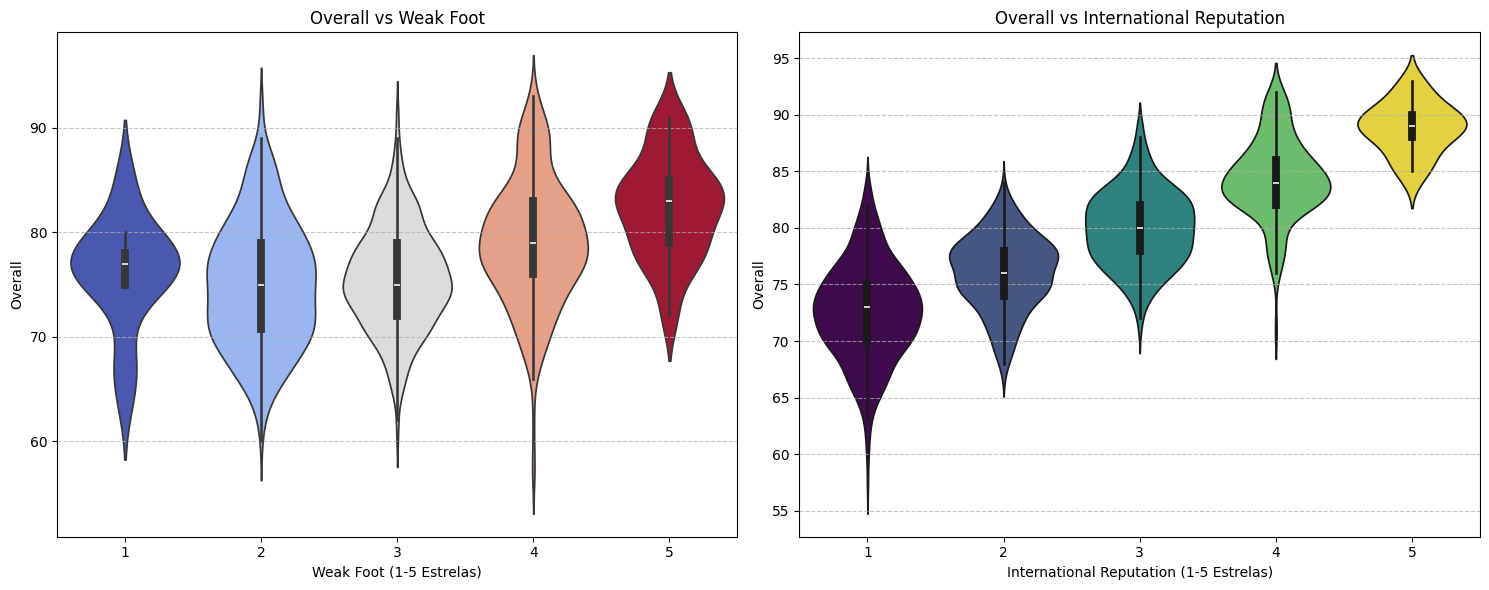

In [128]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x='weak_foot', y='overall', data=df_train, palette='coolwarm', hue='weak_foot', legend=False)
plt.title('Overall vs Weak Foot')
plt.xlabel('Weak Foot (1-5 Estrelas)')
plt.ylabel('Overall')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
sns.violinplot(x='international_reputation', y='overall', data=df_train, palette='viridis', hue='international_reputation', legend=False)
plt.title('Overall vs International Reputation')
plt.xlabel('International Reputation (1-5 Estrelas)')
plt.ylabel('Overall')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Os *violin plots* para atributos ordinais como `weak_foot` e `international_reputation` em relação ao `overall` ilustram a distribuição do atributo alvo para cada categoria desses atributos. Eles permitem verificar se há uma tendência clara onde categorias mais altas (5 estrelas) correspondem a valores de `overall` maiores e como a dispersão do `overall` varia entre as diferentes classes. Essa visualização ajuda a entender a importância e a natureza da influência desses atributos ordinais na nota geral do jogador. Para o atributo `international_reputation`, por exemplo, observa-se que para um valor de 5 estrelas o overall sempre é maior que ~82, assim como com valor de 1 estrela ele não ulrapassa a marca de aproximadamente 86

### 4.6 Explorando Mais Relações Atributo-Alvo (com Linhas de Regressão)

Para ter uma ideia da 'forma da função' que relaciona cada atributo contínuo ao `overall`, podemos usar gráficos de dispersão com uma linha de regressão. Isso ajuda a visualizar a tendência geral e se a relação é linear ou mais complexa.

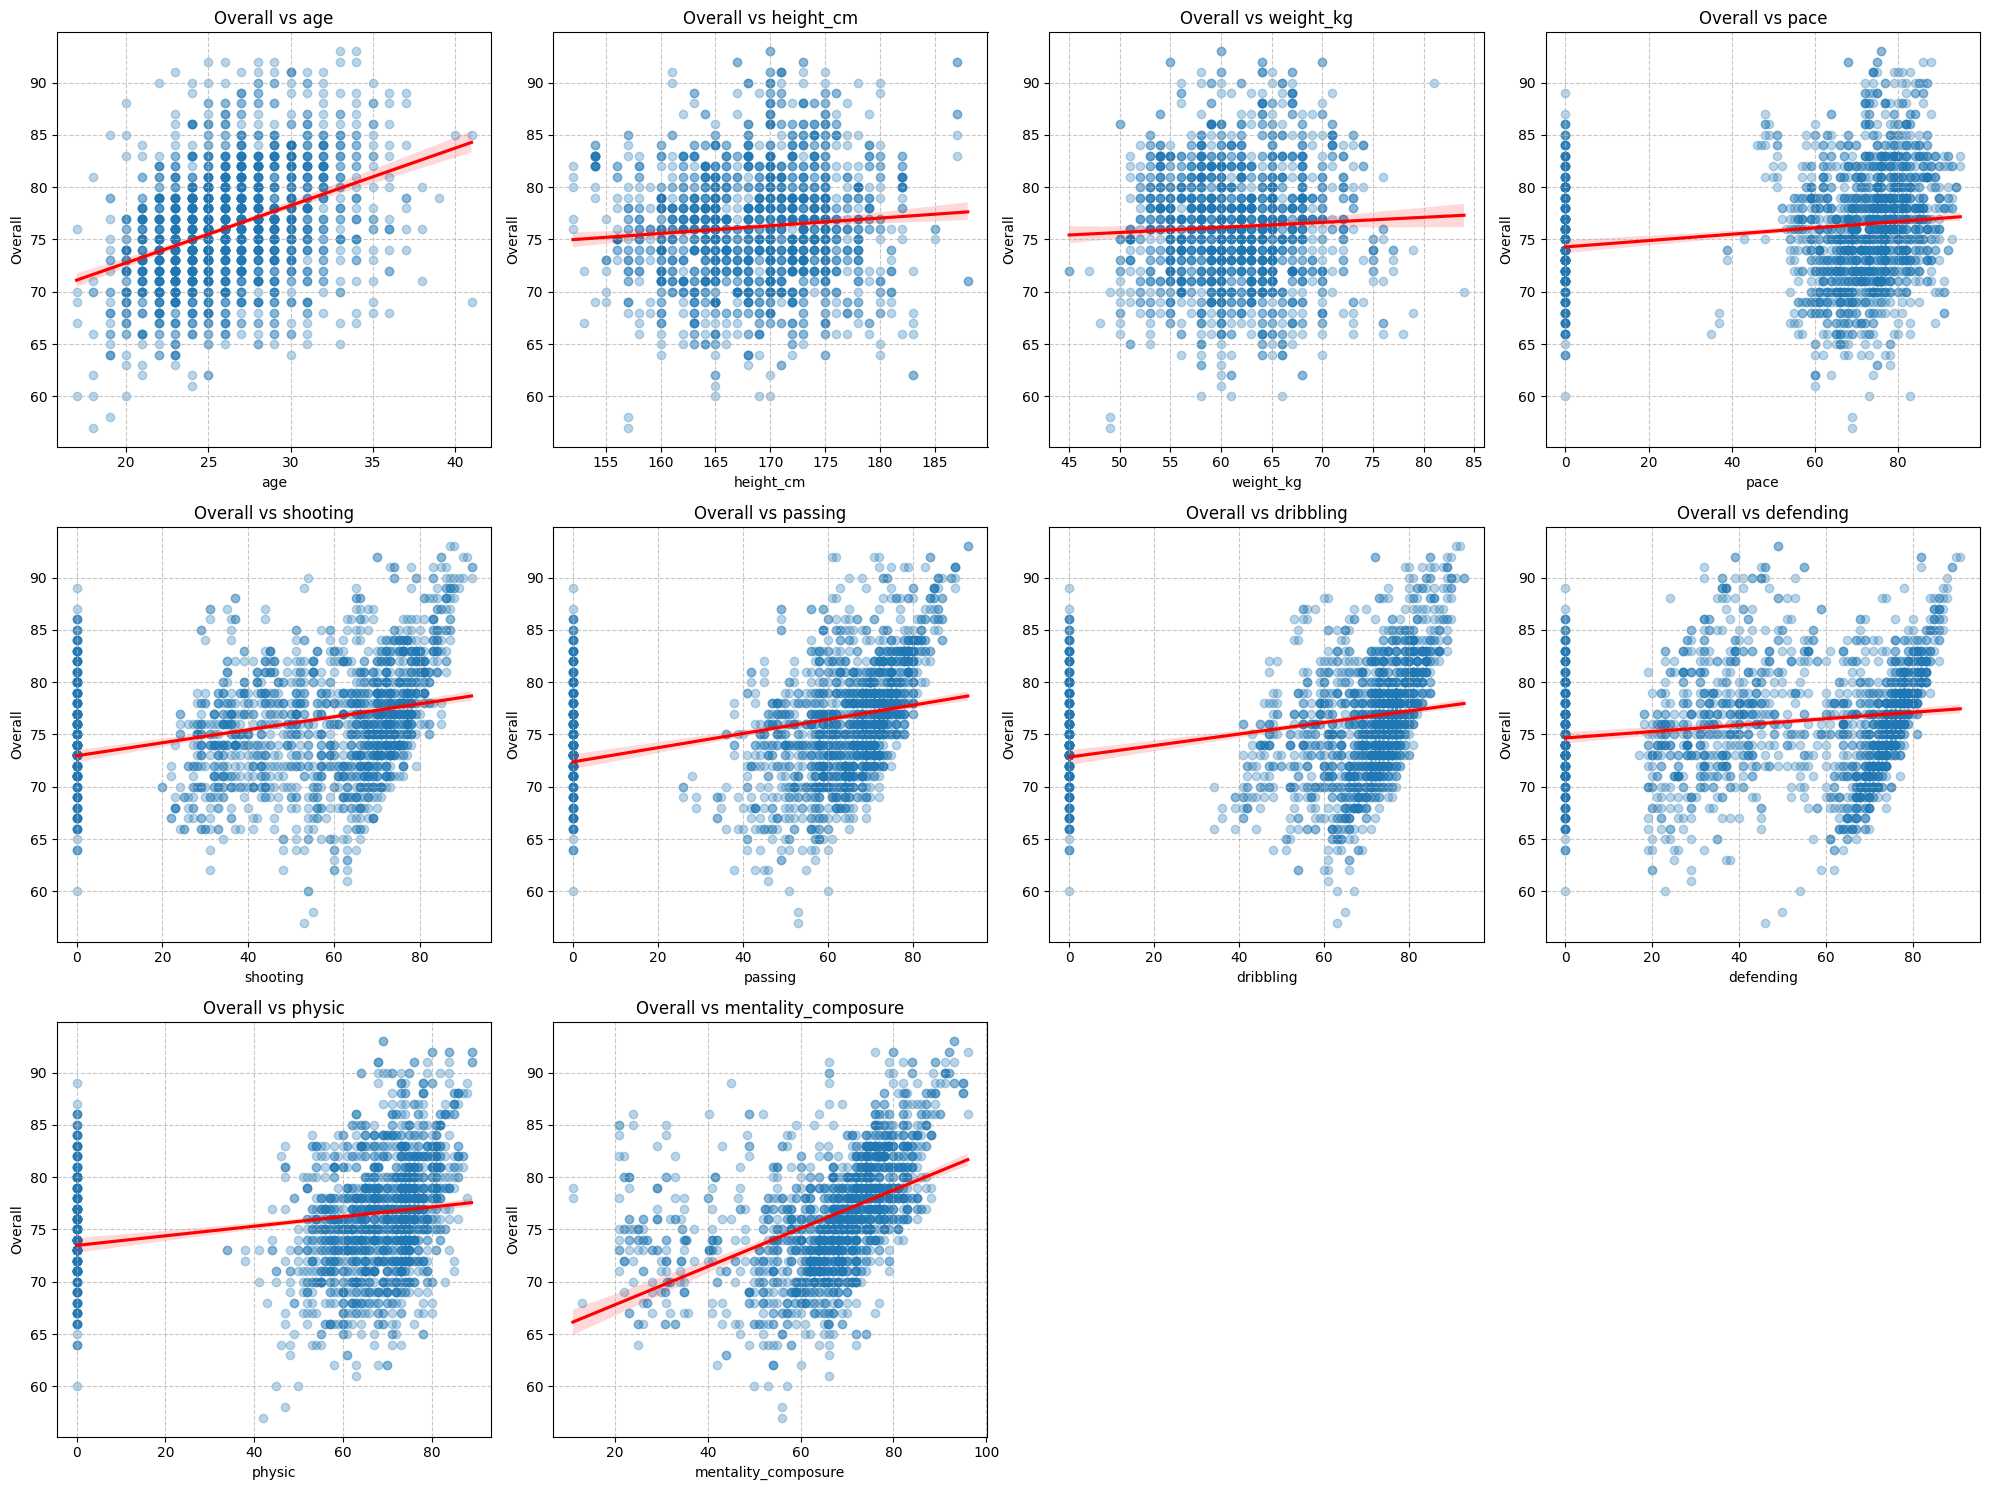

In [129]:
other_continuous_features = [
    'age', 'height_cm', 'weight_kg', 'pace', 'shooting', 'passing',
    'dribbling', 'defending', 'physic', 'mentality_composure'
]

plt.figure(figsize=(20, 15))
for i, feature in enumerate(other_continuous_features):
    plt.subplot(3, 4, i + 1) # 3 linhas, 4 colunas
    sns.regplot(x=df_train[feature], y=df_train['overall'], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'Overall vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Overall')
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Com esses gráficos de dispersão junto a linhas de regressão (regplot) dá pra notar as tendencias lineares de alguns dos atributos quando associados ao `overall`. Eles ajudam a confirmar se a relação entre um atributo preditor e o alvo é linear ou aproximadamente linear, indicando que um aumento no preditor tende a estar associado a um aumento ou diminuição no `overall`. Observando rápidamente da pra perceber que variáveis como `mentality_composure`, `age` e os atributos base tem grande influência sobre o atributo base, além de alguns deles terem um comportamento linear marcante na faixa do 60 a diante

### 4.7 Tabelas de Frequência para Atributos Categóricos/Ordinais

As tabelas de frequência são essenciais para entender a distribuição de atributos categóricos e ordinais, mostrando a contagem e a proporção de cada categoria. Vamos analisar `weak_foot` e `international_reputation`, que são ordinais, e também a distribuição das posições (`is_Position`).

In [130]:
print('**Tabela de Frequência para Weak Foot:**')
display(df_train['weak_foot'].value_counts().sort_index().to_frame(name='Count'))
print('\n**Tabela de Frequência para International Reputation:**')
display(df_train['international_reputation'].value_counts().sort_index().to_frame(name='Count'))

print('\n**Tabela de Frequência para Posições (Top 10 mais comuns):**')
# Somar as colunas 'is_Position' para ver a contagem de jogadores em cada posição
position_counts = df_train[position_columns].sum().sort_values(ascending=False)
display(position_counts.head(10).to_frame(name='Count'))

**Tabela de Frequência para Weak Foot:**


,Count
weak_foot,
1,19
2,336
3,1167
4,272
5,59



**Tabela de Frequência para International Reputation:**


,Count
international_reputation,
1,821
2,491
3,345
4,163
5,33



**Tabela de Frequência para Posições (Top 10 mais comuns):**


,Count
is_ST,431
is_CB,400
is_CM,396
is_CAM,266
is_LB,253
is_RM,249
is_LM,248
is_GK,235
is_RB,223
is_CDM,217


As tabelas de frequência para 'weak_foot', 'international_reputation' e as colunas `is_Position` oferecem uma quantificação da distribuição de cada categoria dentro desses atributos ordinais e binários. Elas mostram a contagem de jogadores em cada nível de proficiência ou em cada posição, permitindo identificar quais categorias são mais ou menos representadas no conjunto de dados. Essa análise é fundamental para entender a composição do dataset e detectar possíveis desequilíbrios que podem influenciar o desempenho dos modelos.

# 5. Modelagem

Nesta etapa, o objetivo é treinar diferentes algoritmos de regressão para prever o *Overall* das jogadoras em 2022 com base em seus atributos históricos. Para avaliar a real eficácia dos modelos de *Machine Learning* propostos pelo grupo (Regressão Linear, Árvore de Decisão e Random Forest), é fundamental criarmos, primeiramente, um **Baseline**.

O modelo *Baseline* funciona como uma "linha de base" não inteligente. Utilizaremos a estratégia da média: ele ignorará todos os atributos técnicos das jogadoras e simplesmente preverá a média do *Overall* de treino para qualquer jogadora do conjunto de teste. O desempenho desse *Baseline* nos dará o parâmetro do "pior cenário possível". A meta de qualquer algoritmo que implementarmos a seguir é superar com folga as métricas geradas por ele.


## 5.1 Baseline (Modelo de Comparação)

O modelo *Baseline* é uma etapa fundamental na avaliação de qualquer solução de *Machine Learning*. Conforme introduzido na seção anterior, ele não incorpora inteligência sofisticada, servindo como um ponto de referência para medir o desempenho real dos nossos modelos mais complexos. Utilizando a estratégia de prever a média do `Overall` do conjunto de treinamento para todos os jogadores no conjunto de teste, o *Baseline* nos oferece o cenário de menor performance aceitável. O objetivo principal é que qualquer modelo 'inteligente' que construirmos demonstre um desempenho significativamente superior a este *Baseline*, validando assim sua utilidade e capacidade preditiva.

--- Resultados do Baseline (Estratégia: Média) ---
MAE: 4.6103
MSE: 33.1546
RMSE: 5.7580



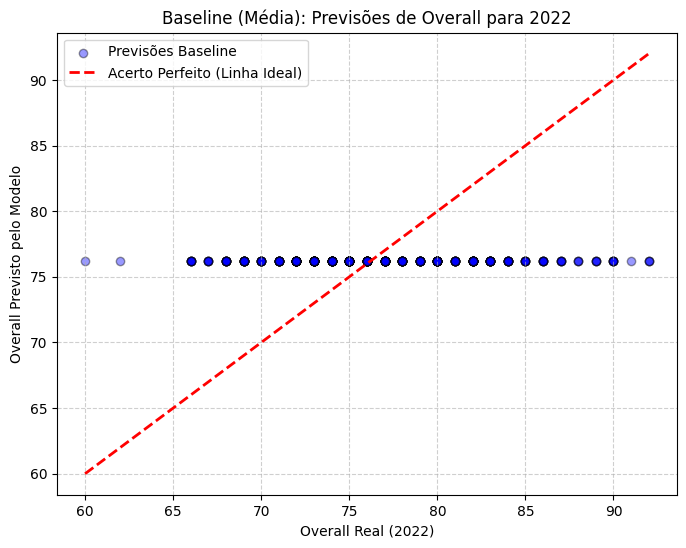

In [131]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# BASELINE (Modelo Base para comparação)
print("--- Resultados do Baseline (Estratégia: Média) ---")
dummy_regr = DummyRegressor(strategy="mean")
dummy_regr.fit(X_train, y_train)
y_pred_baseline = dummy_regr.predict(X_test)

mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
mse_baseline = mean_squared_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mse_baseline)

print(f"MAE: {mae_baseline:.4f}")
print(f"MSE: {mse_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}\n")

# --- GRÁFICO (Real vs Previsto) para o Baseline ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_baseline, alpha=0.4, color='blue', edgecolor='k', label='Previsões Baseline')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Acerto Perfeito (Linha Ideal)')
plt.xlabel('Overall Real (2022)')
plt.ylabel('Overall Previsto pelo Modelo')
plt.title('Baseline (Média): Previsões de Overall para 2022')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5.2 Modelo: Random Forest Regressor

O **Random Forest** foi o algoritmo escolhido por representar uma abordagem robusta baseada em *Ensemble Learning*. Diferente de uma única árvore de decisão (que é propensa ao *overfitting*), o Random Forest cria "florestas" com múltiplas árvores durante o treinamento (definimos `n_estimators=100`) e tira a média das previsões de cada uma.

Esta característica o torna excelente para lidar com dados ligeiramente desbalanceados e para capturar relações complexas e não-lineares (como a relação entre os atributos físicos/técnicos e a nota geral da jogadora). A seguir, treinamos o modelo e calculamos as métricas de erro.

--- Resultados do Random Forest ---
MAE: 0.9058
MSE: 1.5225
RMSE: 1.2339



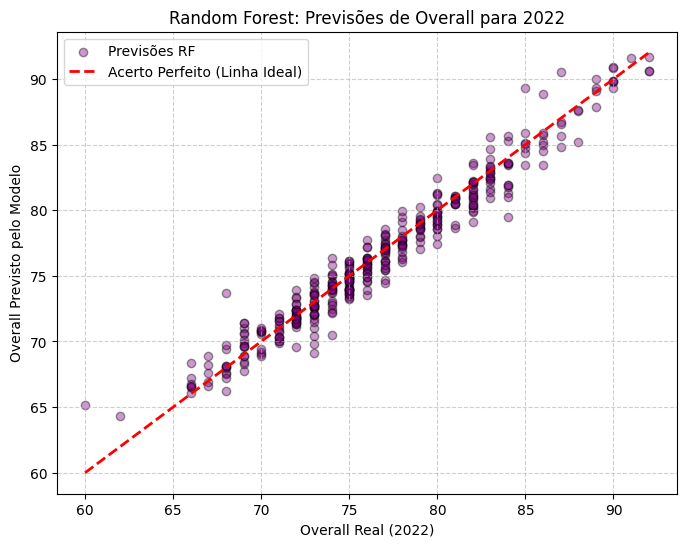

In [132]:
from sklearn.ensemble import RandomForestRegressor

# --- MODELO: RANDOM FOREST ---
print("--- Resultados do Random Forest ---")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print(f"MAE: {mae_rf:.4f}")
print(f"MSE: {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}\n")

# --- GRÁFICO (Real vs Previsto) ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='purple', edgecolor='k', label='Previsões RF')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Acerto Perfeito (Linha Ideal)')
plt.xlabel('Overall Real (2022)')
plt.ylabel('Overall Previsto pelo Modelo')
plt.title('Random Forest: Previsões de Overall para 2022')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5.3 Modelo: Árvore de Decisão para Regressão

A Árvore de Decisão para Regressão (`DecisionTreeRegressor`) é um modelo não-paramétrico que aprende regras de decisão simples dos dados para prever um valor-alvo contínuo. Ela divide o espaço de entrada em regiões e atribui um valor de previsão (a média do alvo naquela região) para cada uma. Embora seja intuitiva e fácil de interpretar, uma única árvore de decisão é suscetível ao *overfitting* se não for devidamente controlada. Vamos treinar uma árvore de decisão e avaliar seu desempenho.


--- Resultados da Árvore de Decisão para Regressão ---
MAE: 1.3376
MSE: 4.0179
RMSE: 2.0045



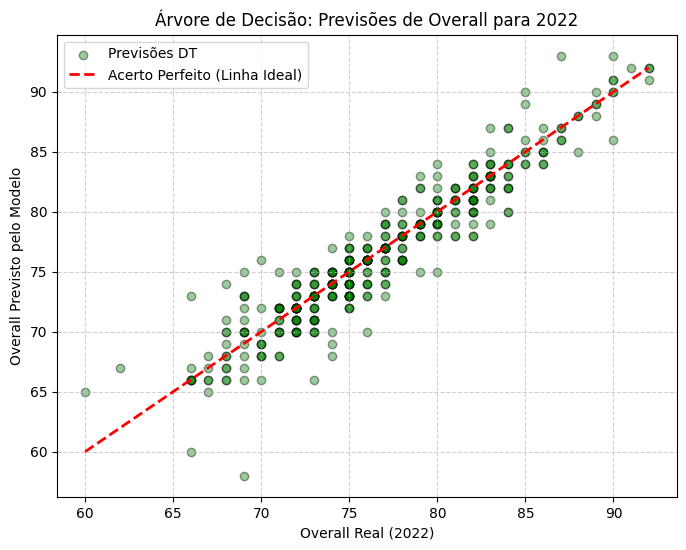

In [133]:
from sklearn.tree import DecisionTreeRegressor

print("--- Resultados da Árvore de Decisão para Regressão ---")
# Inicializa e treina o modelo de Árvore de Decisão
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred_dt = dt_model.predict(X_test)

# Calcula as métricas de avaliação
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

print(f"MAE: {mae_dt:.4f}")
print(f"MSE: {mse_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}\n")

# --- GRÁFICO (Real vs Previsto) para Árvore de Decisão ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.4, color='green', edgecolor='k', label='Previsões DT')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Acerto Perfeito (Linha Ideal)')
plt.xlabel('Overall Real (2022)')
plt.ylabel('Overall Previsto pelo Modelo')
plt.title('Árvore de Decisão: Previsões de Overall para 2022')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 5.4 Modelo: Regressão Linear
A Regressão Linear (LinearRegression) é um modelo paramétrico clássico que busca estabelecer uma relação matemática linear entre as variáveis de entrada para prever um valor-alvo contínuo. Ela ajusta uma linha reta (ou um hiperplano, no caso de múltiplas variáveis) aos dados, minimizando a soma dos quadrados dos resíduos (a diferença entre os valores reais e as previsões). Embora seja altamente interpretável, simples e computacionalmente eficiente, a regressão linear assume que as relações nos dados são estritamente lineares, o que pode levar ao underfitting se a estrutura dos dados for mais complexa ou não-linear.

--- Resultados da Regressão Linear ---
MAE: 1.6830
MSE: 4.5248
RMSE: 2.1272



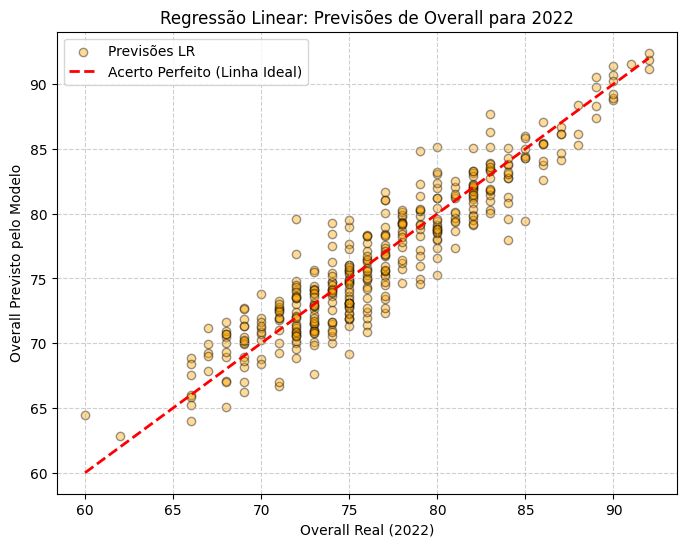

In [134]:
from sklearn.linear_model import LinearRegression

print("--- Resultados da Regressão Linear ---")
# Inicializa e treina o modelo de Regressão Linear
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Faz previsões no conjunto de teste
y_pred_lr = lr_model.predict(X_test)

# Calcula as métricas de avaliação
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print(f"MAE: {mae_lr:.4f}")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}\n")

# --- GRÁFICO (Real vs Previsto) para Regressão Linear ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='orange', edgecolor='k', label='Previsões LR')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Acerto Perfeito (Linha Ideal)')
plt.xlabel('Overall Real (2022)')
plt.ylabel('Overall Previsto pelo Modelo')
plt.title('Regressão Linear: Previsões de Overall para 2022')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [135]:
print("--- Comparação dos Modelos ---")

# Criação de um DataFrame para estruturar os resultados
resultados = pd.DataFrame({
    'Modelo': ['Baseline ', 'Árvore de Decisão', 'Random Forest', 'Regressão Linear'],
    'MAE': [mae_baseline, mae_dt, mae_rf, mae_lr],
    'MSE': [mse_baseline, mse_dt, mse_rf, mse_lr],
    'RMSE': [rmse_baseline, rmse_dt, rmse_rf, rmse_lr]
})

# Ordenando do menor (melhor) para o maior erro absoluto médio
resultados = resultados.sort_values(by='MAE').reset_index(drop=True)

# Exibindo a tabela formatada
display(resultados.style.highlight_min(subset=['MAE', 'MSE', 'RMSE'], color='green'))

--- Comparação dos Modelos ---


,Modelo,MAE,MSE,RMSE
0,Random Forest,0.905806,1.522458,1.233879
1,Árvore de Decisão,1.337596,4.017903,2.004471
2,Regressão Linear,1.683050,4.524838,2.127167
3,Baseline,4.610262,33.154566,5.758000


# 6. Resultados e Discussões



O Modelo escolhido como melhor foi o **Random Forest**, por ter obtido o menor erro absoluto (MAE), erro quadrático médio (MSE) e raiz do erro quadrático médio (RMSE) com base nos resultados apresentados nos testes.

## 6.1 Erros Observados

Mesmo o melhor modelo (Random Forest) ainda apresenta erros, embora menores. O MAE de 0.9058 significa que, em média, as previsões do modelo se desviam do overall real em menos de um ponto. O RMSE de 1.2339, estando na mesma escala do overall, indica que a dispersão dos erros ainda existe, mas é significativamente menor que a do Baseline. Para os modelos de Árvore de Decisão e Regressão Linear, os erros são progressivamente maiores, com a Regressão Linear mostrando uma dificuldade maior em capturar a complexidade dos dados devido à sua natureza linear.

## 6.2 Limitações

1. Confiabilidade em Outliers

Modelos de regressão, e especialmente os baseados em árvores, podem ter desempenho reduzido para prever overalls muito altos ou muito baixos (outliers), pois há menos dados de treinamento nessas faixas. O Random Forest, embora robusto, ainda pode ter dificuldade em extrapolar além do range de dados observados no treinamento.

2. Interpretabilidade

Embora o Random Forest seja preciso, ele é menos interpretável que a Regressão Linear. Entender exatamente como cada atributo contribui para a previsão final do overall é mais desafiador.

## 6.2 Possiveis Melhorias

1. Otimização de Hiperparâmetros (Tuning)

Embora o Random Forest tenha se saído bem, a otimização de seus hiperparâmetros (n_estimators, max_depth, min_samples_split) via GridSearchCV ou RandomizedSearchCV poderia melhorar ainda mais seu desempenho.

2. Features Avançadas

Criar novas features a partir das existentes (razões entre atributos, atributos de interação) poderia fornecer informações mais ricas para os modelos.

3. Tratamento inteligente de variáveis ausentes

É possível que a atribuição de zeros aos atributos de campo tenha dificultado o aprendizado dos modelos, já que isso alterou a distribuição dos dados e sua interpretabilidade. Foi considerado utilizar média por overall como forma de preencher esses campos vazios, mas isso imputou comportamento linear e prejudicou ainda mais a precisão dos modelos.